In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("/home/sambt/CASE_final/CASE_QUAK_final/commonTools/")
import helper_functions as hf
import qRegNN_NFs_general as qrnn
import sklearn
import scipy
import sklearn.datasets as datasets
import h5py
import os
import pandas as pd
import corner
from sklearn.model_selection import train_test_split
sys.path.append("/home/sambt/SINF/")
sys.path.append("/home/sambt/SINF/sinf/")
from GIS import GIS
import torch
import torch.nn as nn
device = torch.device('cuda:0')
import uproot
from tqdm import tqdm
import h5py

In [2]:
# make train/test/val split indices for R&D dataset bkg
base = "/nobackup/users/sambt/QR_samples/LHCO/contrastive/"
f_rd = f"{base}/rd_bkg_latent.h5"
f_b1 = f"{base}/bb1_bkg_latent.h5"
with h5py.File(f_rd,'r') as f:
    rd = f['space'][()]
with h5py.File(f_b1,'r') as f:
    b1 = f['space'][()]
    
rd_train, rd_test = train_test_split(rd,train_size=0.75)
b1_train, b1_test = train_test_split(b1,train_size=0.75)
fitvars = [f"latent{i}" for i in range(b1.shape[1])]

In [16]:
flow_rd = GIS(torch.tensor(rd_train[:,:1],dtype=torch.float32,device=device), 
           torch.tensor(rd_test[:,:1],dtype=torch.float32,device=device), 
            Whiten=True, 
            batchsize=50000, 
            nocuda=False,
           edge_bins=40,
            M=200,
            K=1,
           iteration=1000,
            verbose=True)

After whiten logp: -1.0129976272583008 -1.0088469982147217
Fit spline Time: 0.021361663818359376
logp: -0.997031569480896 -0.9932745695114136 time: 0.04935932159423828 iteration: 2 best: 2
Fit spline Time: 0.021948415756225585
logp: -0.9844401478767395 -0.9810217618942261 time: 0.05101513862609863 iteration: 3 best: 3
Fit spline Time: 0.021950464248657226
logp: -0.9744696617126465 -0.9713438153266907 time: 0.04943585395812988 iteration: 4 best: 4
Fit spline Time: 0.021956607818603514
logp: -0.966546893119812 -0.9636746644973755 time: 0.04936528205871582 iteration: 5 best: 5
Fit spline Time: 0.022598655700683593
logp: -0.9602330923080444 -0.9575817584991455 time: 0.0502164363861084 iteration: 6 best: 6
Fit spline Time: 0.021999616622924805
logp: -0.9551900625228882 -0.952731728553772 time: 0.04948019981384277 iteration: 7 best: 7
Fit spline Time: 0.022025215148925782
logp: -0.9511547684669495 -0.9488658905029297 time: 0.049497127532958984 iteration: 8 best: 8
Fit spline Time: 0.02199756

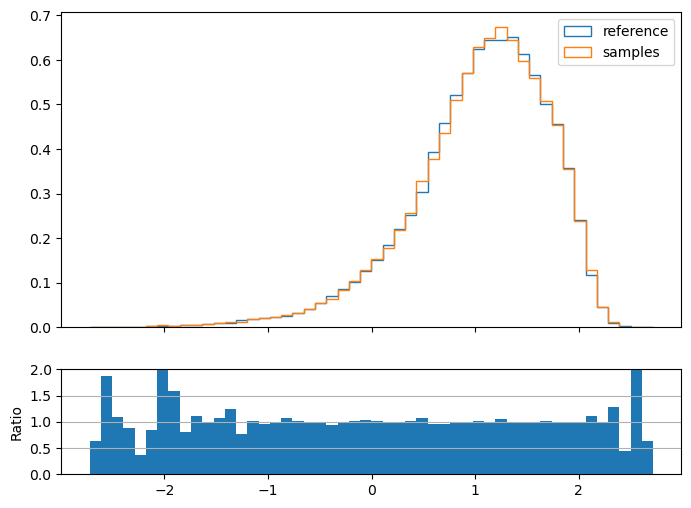

In [17]:
with torch.no_grad():
    samples = flow_rd.sample(100000)[0].detach().cpu().numpy()
qrnn.plotPair(rd_test[:,0],samples[:,0],log=False,ylim=[0,2])

In [18]:
flow_b1 = GIS(torch.tensor(b1_train[:,:1],dtype=torch.float32,device=device), 
           torch.tensor(b1_test[:,:1],dtype=torch.float32,device=device), 
            Whiten=True, 
            batchsize=50000, 
            nocuda=False,
           edge_bins=40,
            M=200,
            K=1,
           iteration=1000,
            verbose=True)

After whiten logp: -1.13993239402771 -1.1378105878829956
Fit spline Time: 0.02370969581604004
logp: -1.123387098312378 -1.121587872505188 time: 0.05924820899963379 iteration: 2 best: 2
Fit spline Time: 0.024748031616210937
logp: -1.1103761196136475 -1.1088883876800537 time: 0.0530085563659668 iteration: 3 best: 3
Fit spline Time: 0.022001663208007814
logp: -1.100098967552185 -1.0989067554473877 time: 0.04952859878540039 iteration: 4 best: 4
Fit spline Time: 0.022013952255249023
logp: -1.091950535774231 -1.0910344123840332 time: 0.05110502243041992 iteration: 5 best: 5
Fit spline Time: 0.022040576934814454
logp: -1.0854703187942505 -1.0848102569580078 time: 0.049706220626831055 iteration: 6 best: 6
Fit spline Time: 0.021968896865844727
logp: -1.0803042650222778 -1.0798802375793457 time: 0.049512624740600586 iteration: 7 best: 7
Fit spline Time: 0.021972991943359374
logp: -1.0761783123016357 -1.0759707689285278 time: 0.049463748931884766 iteration: 8 best: 8
Fit spline Time: 0.0219494400

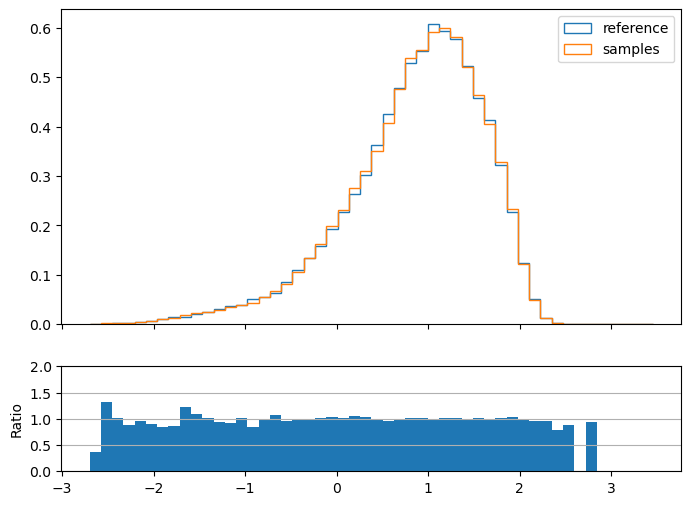

In [19]:
with torch.no_grad():
    samples = flow_b1.sample(100000)[0].detach().cpu().numpy()
qrnn.plotPair(b1_test[:,0],samples[:,0],log=False,ylim=[0,2])

In [21]:
with torch.no_grad():
    noise_train = flow_rd(torch.tensor(rd_train[:,:1],device=device,dtype=torch.float32))[0]
    corr_train = flow_b1.inverse(noise_train)[0].detach().cpu().numpy()
    noise_test = flow_rd(torch.tensor(rd_test[:,:1],device=device,dtype=torch.float32))[0]
    corr_test = flow_b1.inverse(noise_test)[0].detach().cpu().numpy()

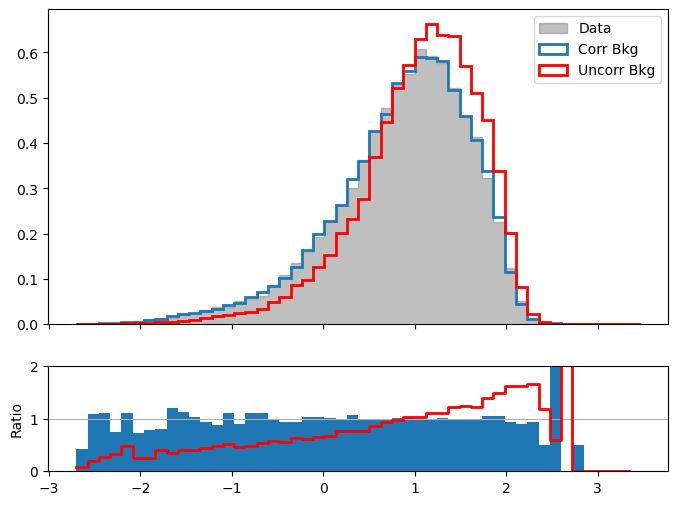

In [22]:
qrnn.plotTriplet(b1_test[:,0],corr_test[:,0],rd_test[:,0])

In [24]:
rd_train[:,0] = corr_train[:,0]
rd_test[:,0] = corr_test[:,0]

# Run morphing

In [4]:
# Try box-cox preprocessing
from scipy.stats import boxcox
mins = np.min(np.concatenate([np.min(a,axis=0).reshape(1,-1) for a in[rd_train,rd_test,b1_train,b1_test]],axis=0),axis=0)
maxes = np.max(np.concatenate([np.max(a,axis=0).reshape(1,-1) for a in[rd_train,rd_test,b1_train,b1_test]],axis=0),axis=0)
fit = 1+(rd_train-mins)/(maxes-mins)
lams = []
corrs = []
for i in range(fit.shape[1]):
    corr,lam = boxcox(fit[:,i])
    lams.append(lam)
    corrs.append(corr)

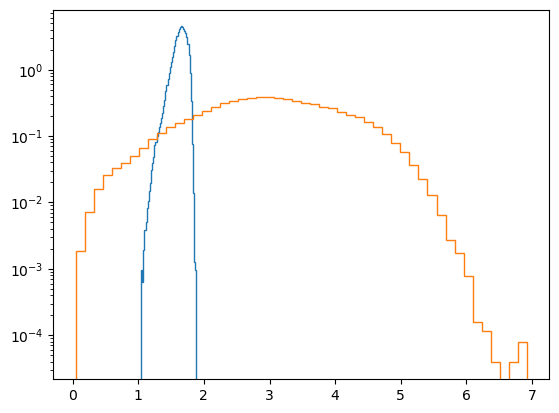

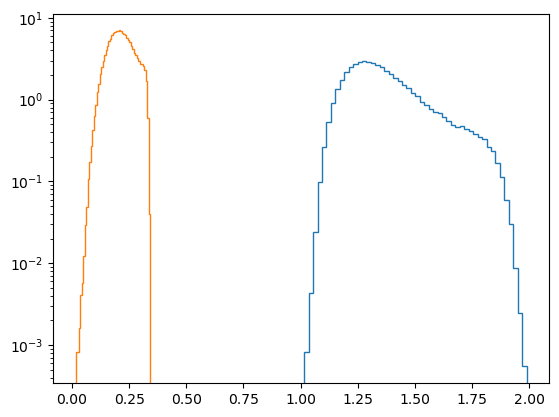

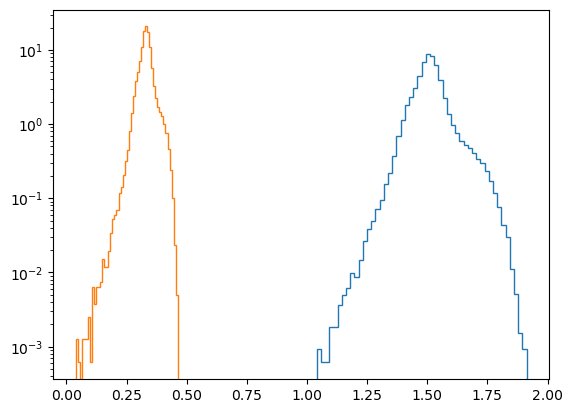

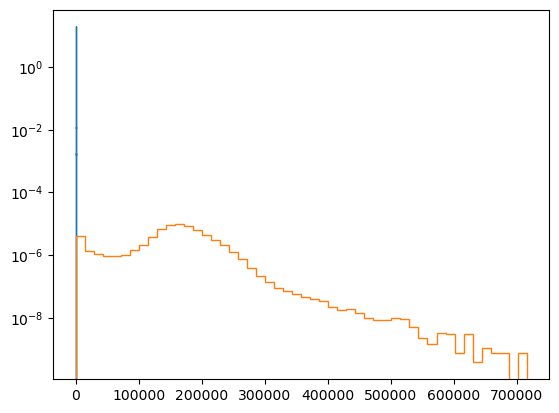

In [6]:
for i in range(rd_train.shape[1]):
    plt.figure()
    h1,bins,_ = plt.hist(fit[:,i],histtype='step',bins=50,density=True)
    h1,bins,_ = plt.hist(corrs[i],histtype='step',bins=50,density=True)
    #h1,bins,_ = plt.hist(logs[:,i],histtype='step',bins=50,density=True)
    plt.yscale('log')

In [7]:
rd_train_bc = []
rd_test_bc = []
b1_train_bc = []
b1_test_bc = []
for i in range(rd_train.shape[1]):
    rd_train_bc.append(boxcox(1+(rd_train[:,i]-mins[i])/(maxes[i]-mins[i]),lmbda=lams[i]).reshape(-1,1))
    rd_test_bc.append(boxcox(1+(rd_test[:,i]-mins[i])/(maxes[i]-mins[i]),lmbda=lams[i]).reshape(-1,1))
    b1_train_bc.append(boxcox(1+(b1_train[:,i]-mins[i])/(maxes[i]-mins[i]),lmbda=lams[i]).reshape(-1,1))
    b1_test_bc.append(boxcox(1+(b1_test[:,i]-mins[i])/(maxes[i]-mins[i]),lmbda=lams[i]).reshape(-1,1))
rd_train_bc = np.concatenate(rd_train_bc,axis=1)
rd_test_bc = np.concatenate(rd_test_bc,axis=1)
b1_train_bc = np.concatenate(b1_train_bc,axis=1)
b1_test_bc = np.concatenate(b1_test_bc,axis=1)

mean,std = rd_train_bc.mean(axis=0),rd_train_bc.std(axis=0)
rd_train_bc = (rd_train_bc-mean)/std
rd_test_bc = (rd_test_bc-mean)/std
b1_train_bc = (b1_train_bc-mean)/std
b1_test_bc = (b1_test_bc-mean)/std

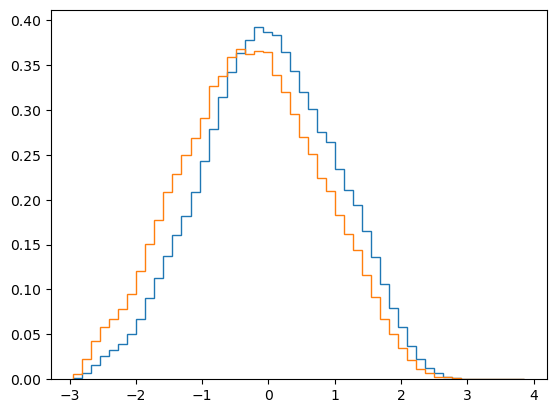

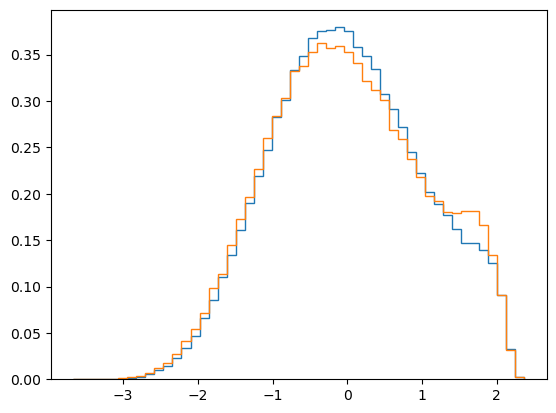

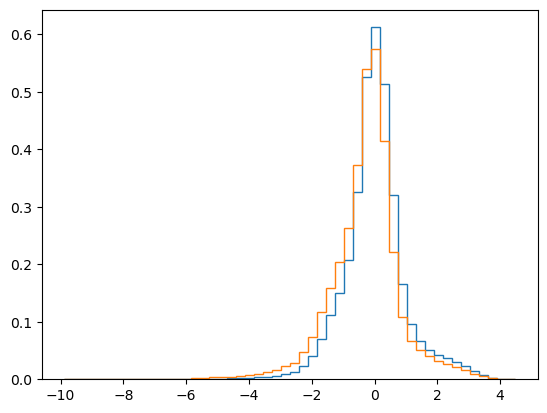

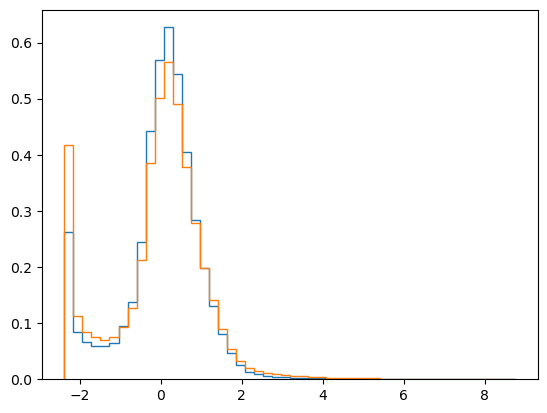

In [8]:
for i in range(rd_train_bc.shape[1]):
    plt.figure()
    h1,bins,_ = plt.hist(rd_train_bc[:,i],histtype='step',bins=50,density=True)
    h2,bins,_ = plt.hist(b1_train_bc[:,i],histtype='step',bins=bins,density=True)

In [28]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":5.2,"hidden_features":100,
             "num_layers":5,"num_bins":30,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
rangeScale = 5
variables = fitvars
trainer = qrnn.chainedNFTrainer("LHCO_contrastive_RDtoBB1_jet1_boxcox",rd_train_bc,rd_test_bc,b1_train_bc,b1_test_bc,fitvars,control=[],
                                NF_kwargs=NF_kwargs,rangeScale=rangeScale,separateScale=False,minmax=False)

# latent 1

Training flow bkgFlow_step0_latent0


Loss: 1.4097387790679932, p = 117: 100%|██████████| 228/228 [00:29<00:00,  7.67it/s]


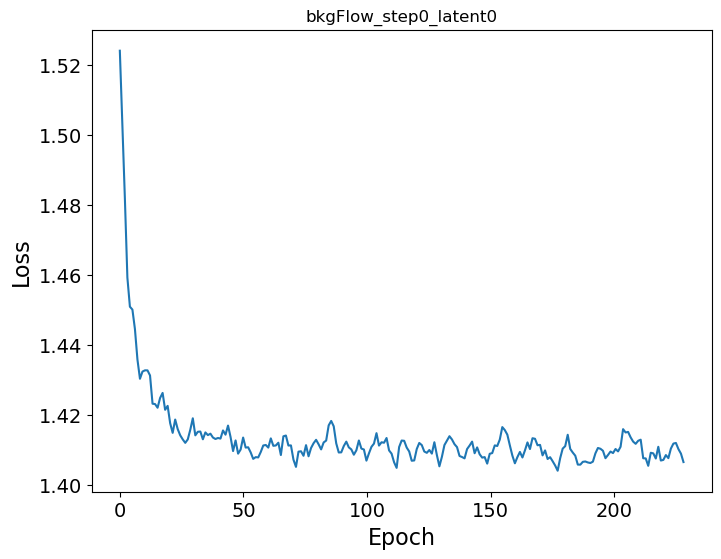

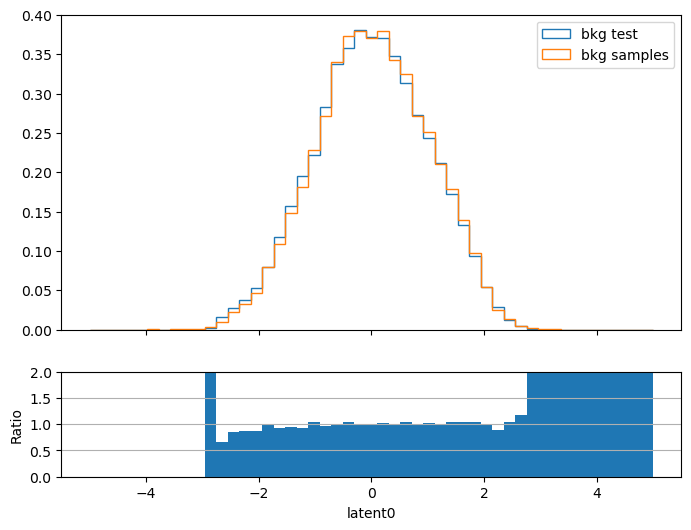

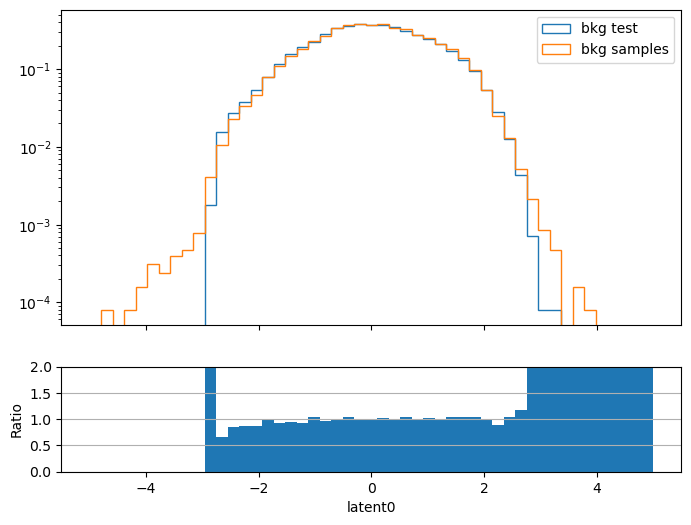

In [32]:
NF_kwargs = {"flow_type":"NSRATQUAD","tail_bound":5,"hidden_features":100,
             "num_layers":1,"num_bins":100,"num_blocks_per_layer":1,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 8192
n_epoch = 10
n_iter = n_epoch*b1_train.shape[0]//bs
trainer.trainCurrentBkg(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(bkg=True,ylim=[0,2])

Training flow dataFlow_step0_latent0


Loss: 1.4459309303760528, p = 97: 100%|██████████| 228/228 [00:29<00:00,  7.72it/s]


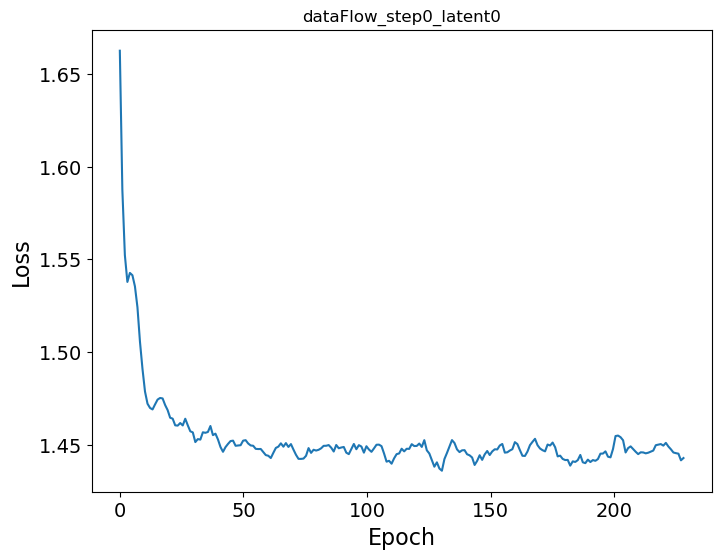

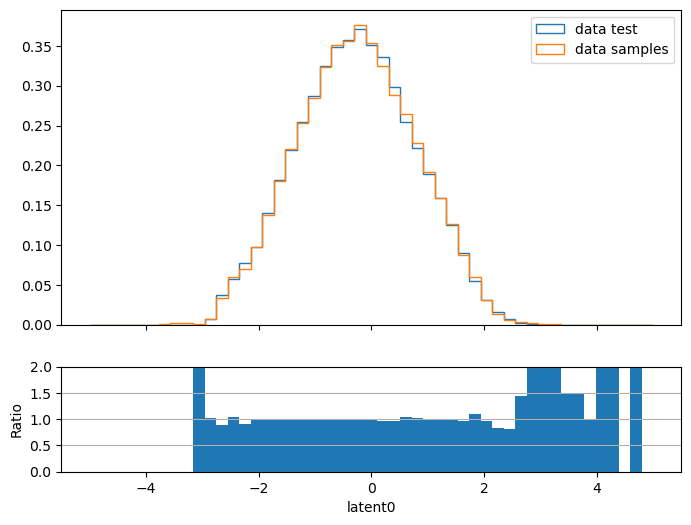

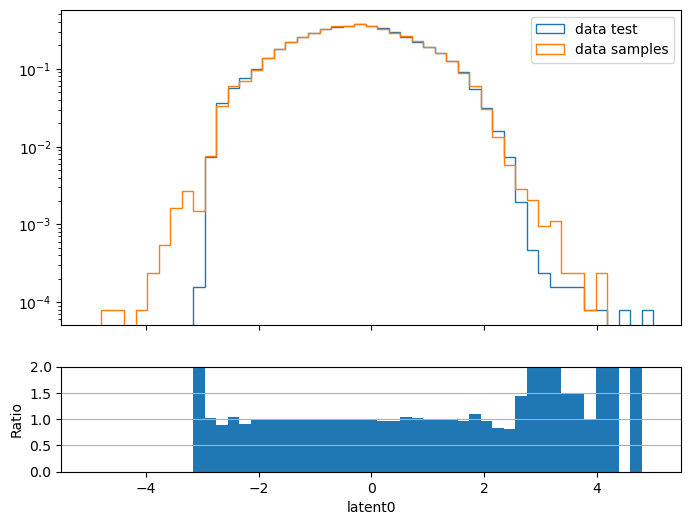

In [33]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":5,"hidden_features":100,
             "num_layers":1,"num_bins":30,"num_blocks_per_layer":1,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 8192
n_epoch = 10
n_iter = n_epoch*b1_train.shape[0]//bs
trainer.trainCurrentData(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(data=True,ylim=[0,2])

100%|██████████| 7/7 [00:00<00:00, 77.38it/s]


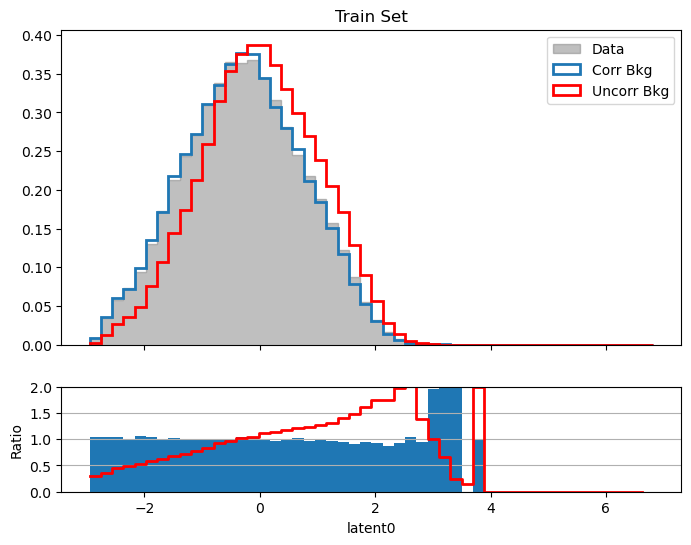

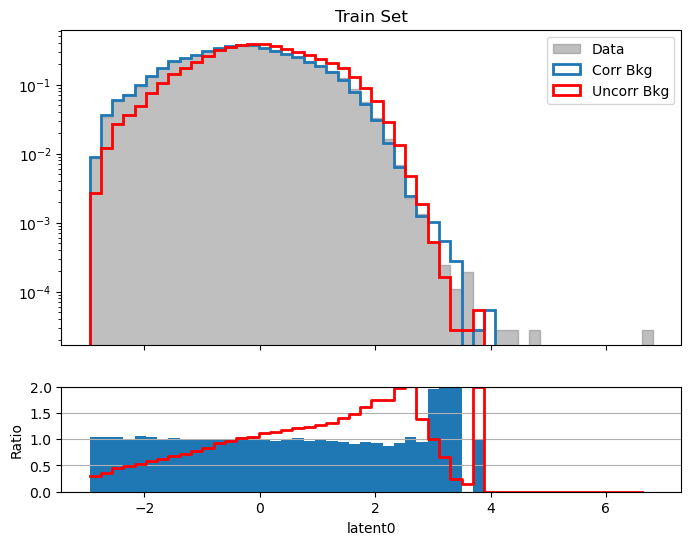

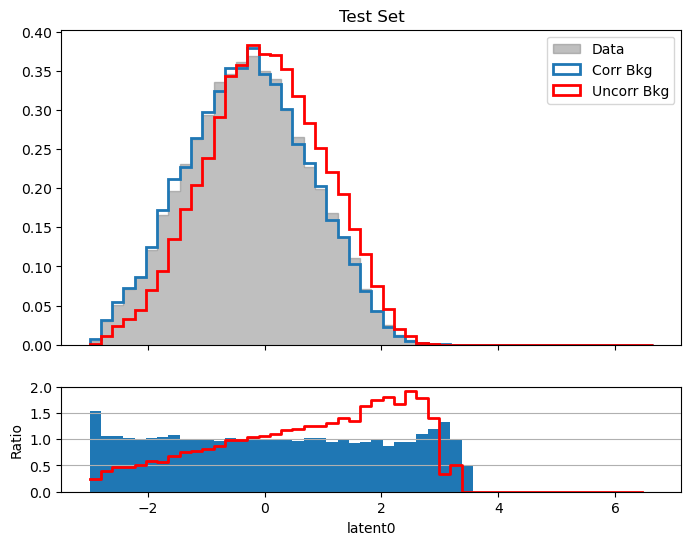

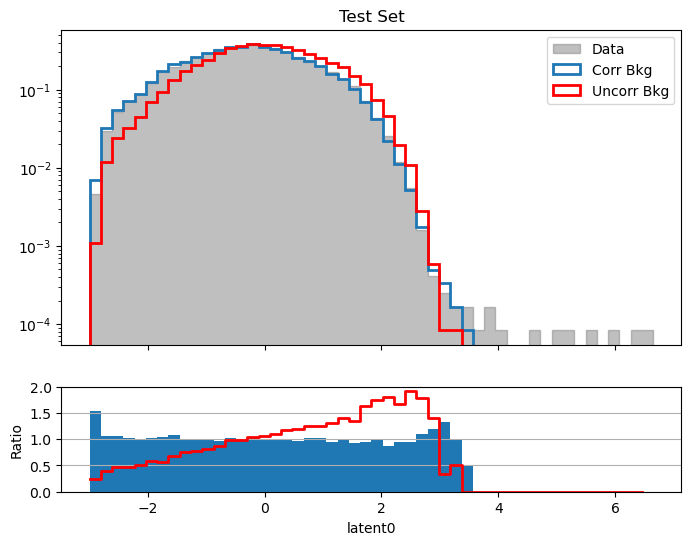

In [34]:
trainer.correctCurrent()
trainer.plotCurrent(50,ylim=[0,2])

In [35]:
trainer.stepForward()

# latent 2

100%|██████████| 7/7 [00:00<00:00, 15.78it/s]


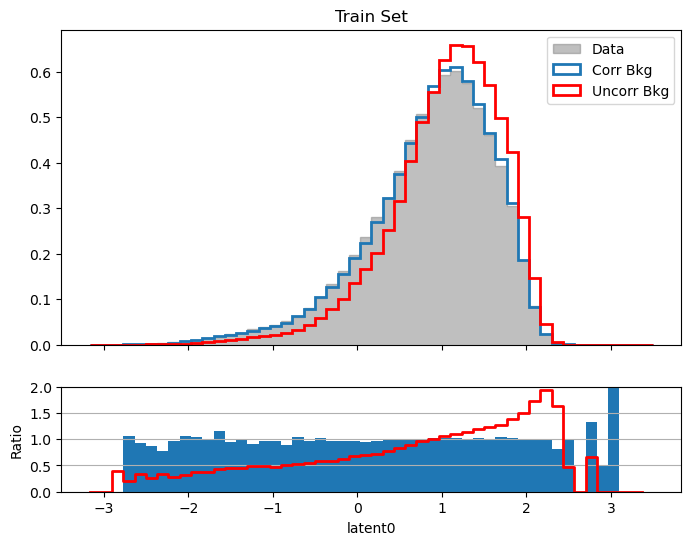

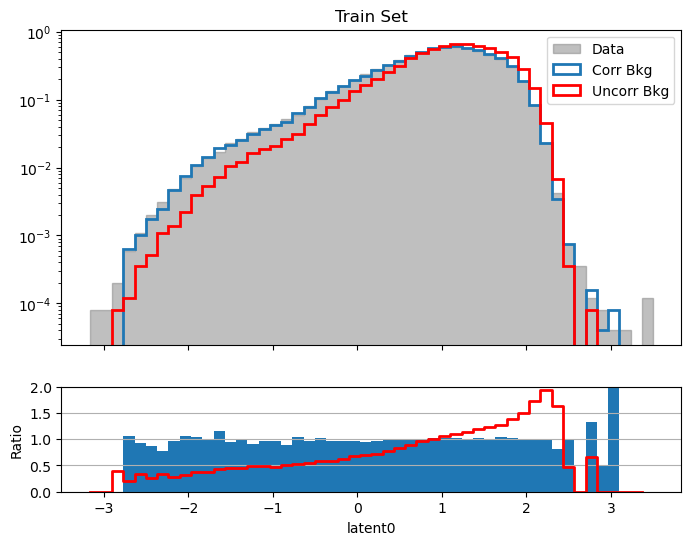

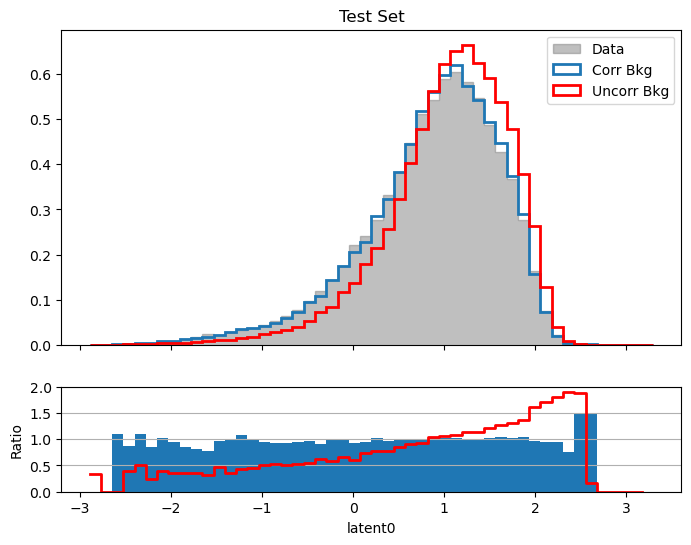

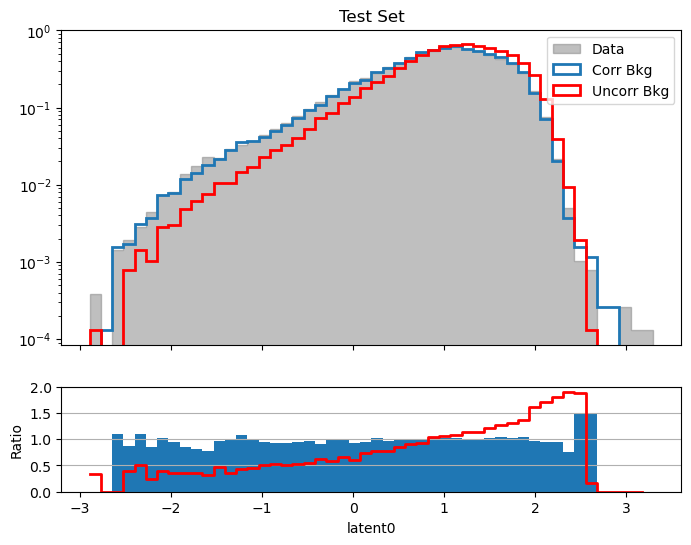

In [4]:
trainer.loadCurrent()
trainer.correctCurrent()
trainer.plotCurrent(50,ylim=[0,2])

In [5]:
trainer.stepForward()

Training flow bkgFlow_step1_latent1


Loss: 1.0086489683389663, p = 71: 100%|██████████| 1463/1463 [00:17<00:00, 84.11it/s] 


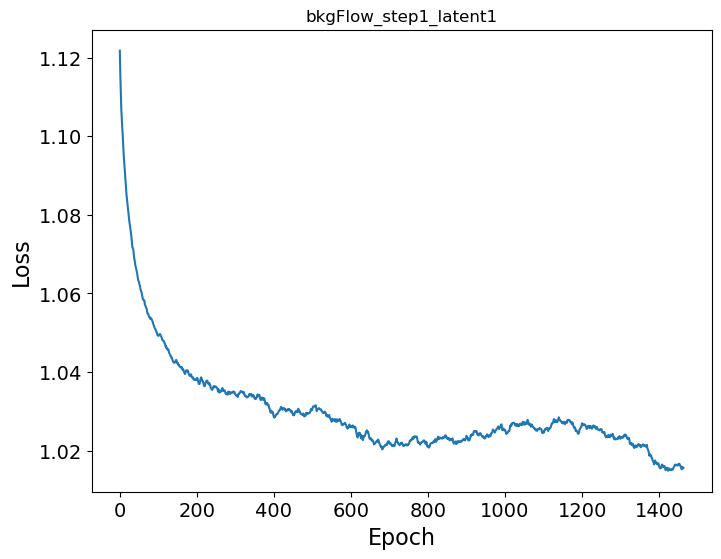

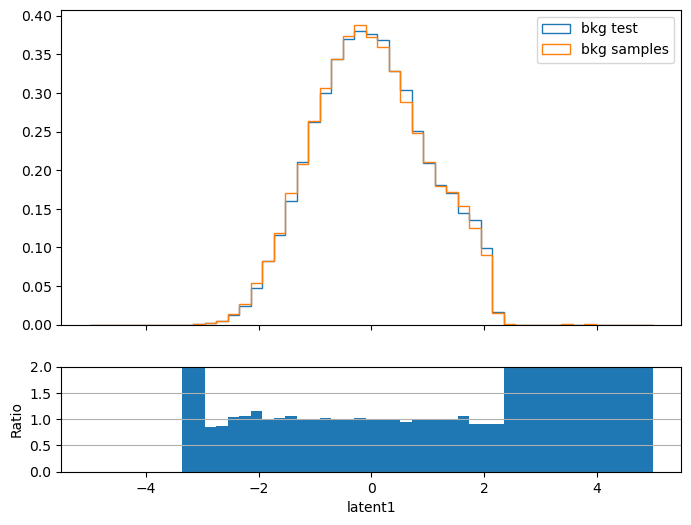

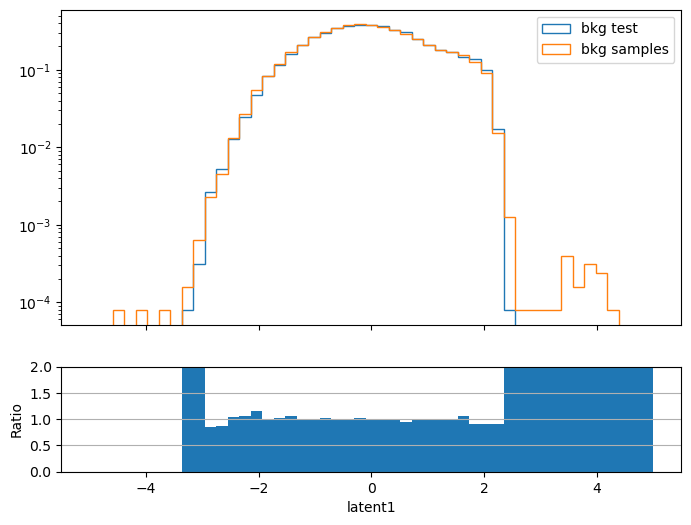

In [37]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":5,"hidden_features":100,
             "num_layers":1,"num_bins":10,"num_blocks_per_layer":1,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 128
n_epoch = 1
n_iter = n_epoch*b1_train.shape[0]//bs
trainer.trainCurrentBkg(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(bkg=True,ylim=[0,2])

Training flow dataFlow_step1_latent1


Loss: 1.1799234818386775, p = 1: 100%|██████████| 93/93 [00:14<00:00,  6.30it/s] 


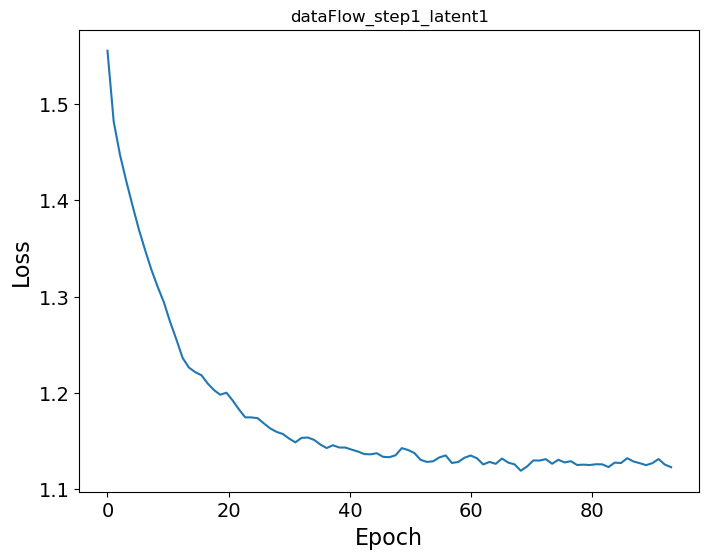

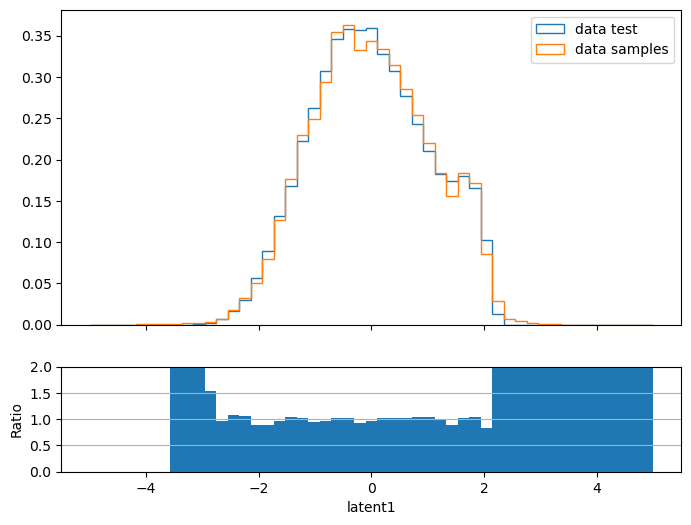

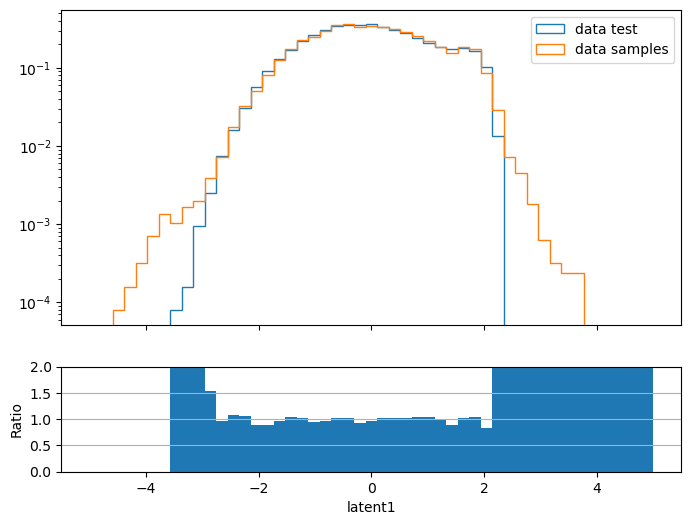

In [43]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":5,"hidden_features":100,
             "num_layers":1,"num_bins":15,"num_blocks_per_layer":1,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 5
n_iter = n_epoch*b1_train.shape[0]//bs
trainer.trainCurrentData(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(data=True,ylim=[0,2])

100%|██████████| 7/7 [00:00<00:00, 16.22it/s]


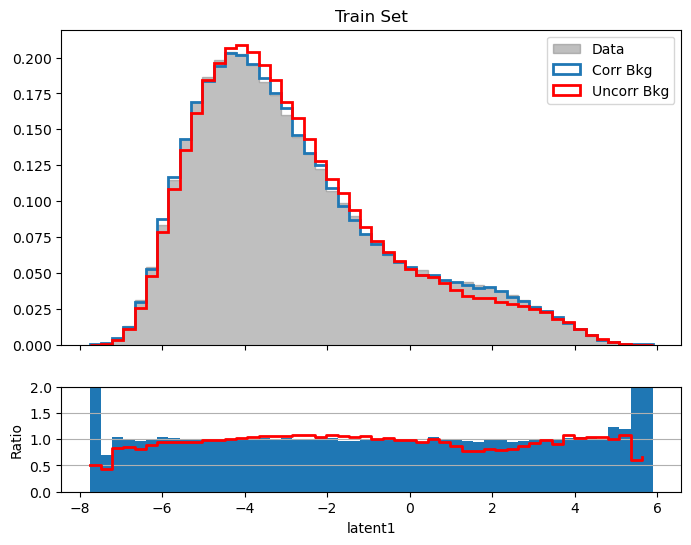

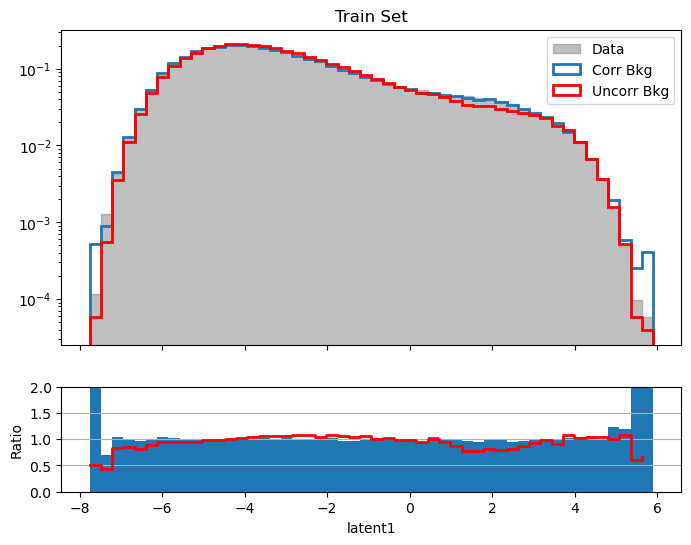

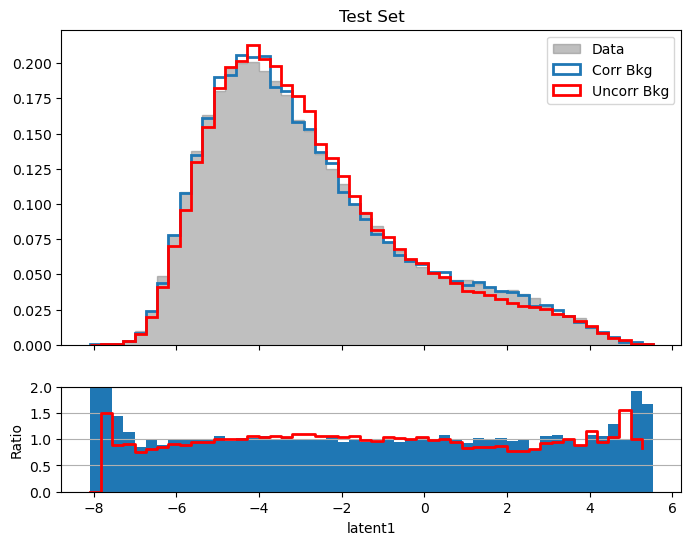

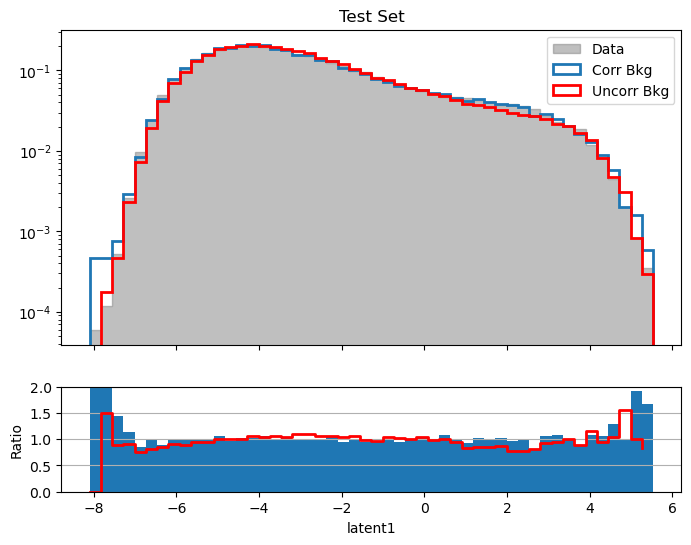

In [25]:
#trainer.loadCurrent()
trainer.correctCurrent()
trainer.plotCurrent(50,ylim=[0,2])

In [26]:
trainer.stepForward()

# latent 3

Training flow bkgFlow_step2_latent2


Loss: -0.7714398992061615, p = 177: 100%|██████████| 686/686 [01:59<00:00,  5.72it/s]


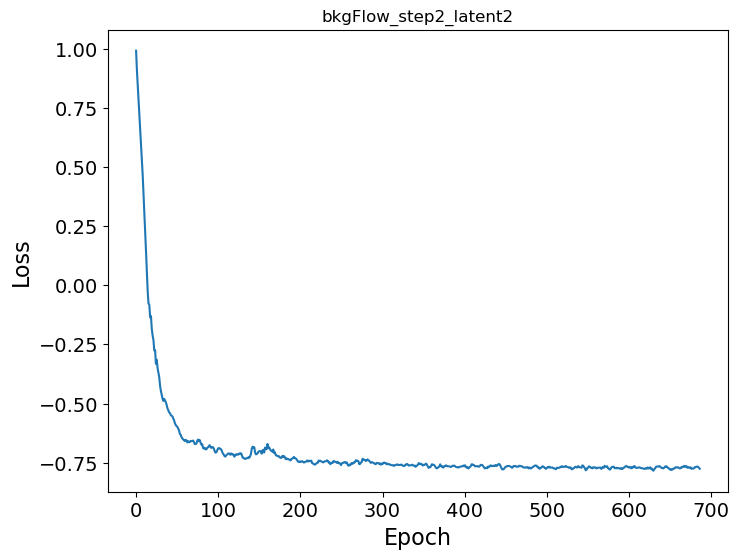

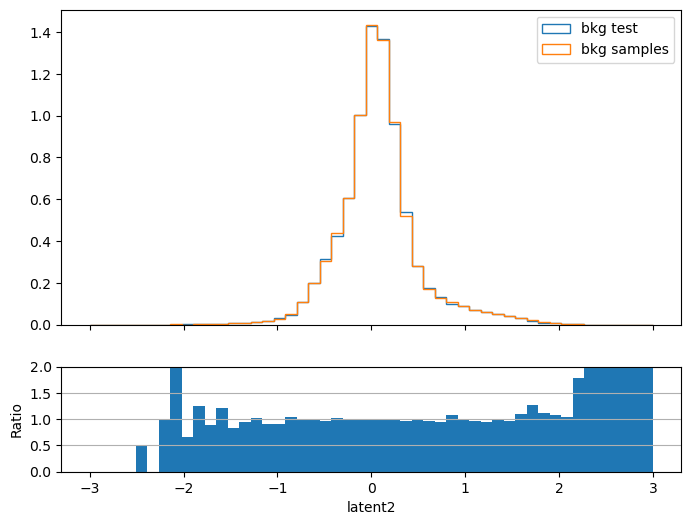

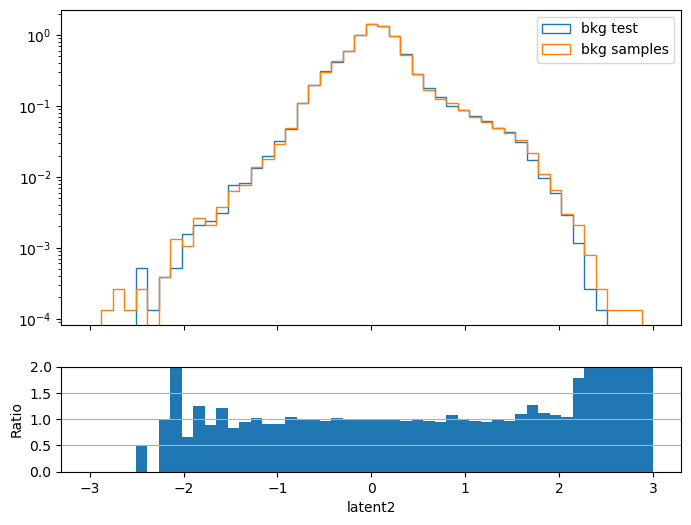

In [27]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":100,
             "num_layers":5,"num_bins":30,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 8192
n_epoch = 30
n_iter = n_epoch*b1_train.shape[0]//bs
trainer.trainCurrentBkg(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(bkg=True,ylim=[0,2])

Training flow dataFlow_step2_latent2


Loss: -0.7718641626834869, p = 77: 100%|██████████| 686/686 [01:59<00:00,  5.72it/s]


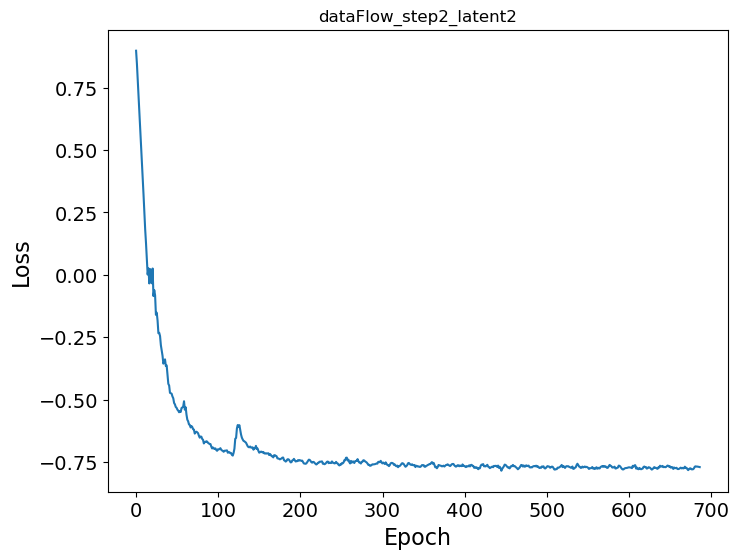

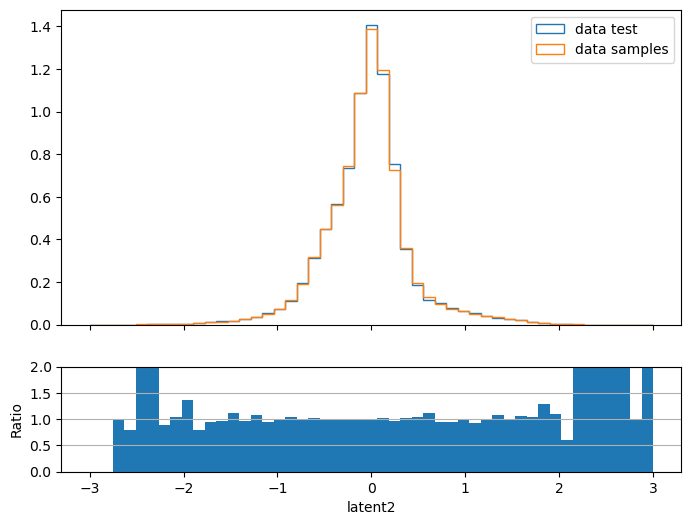

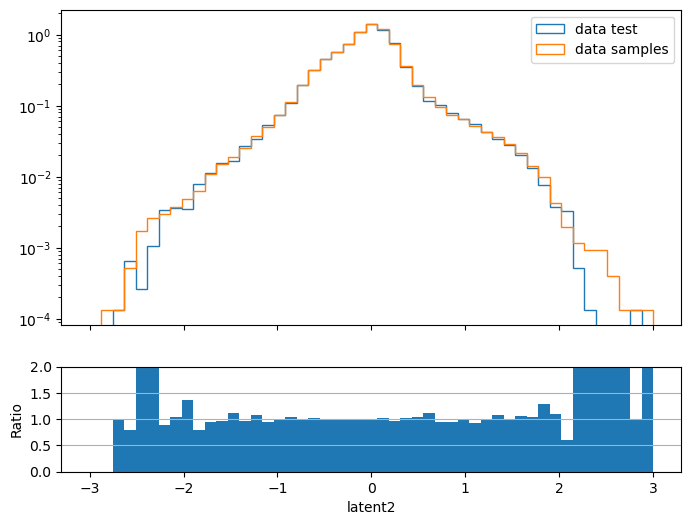

In [28]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":100,
             "num_layers":5,"num_bins":30,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 8192
n_epoch = 30
n_iter = n_epoch*b1_train.shape[0]//bs
trainer.trainCurrentData(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(data=True,ylim=[0,2])

100%|██████████| 7/7 [00:00<00:00, 16.09it/s]


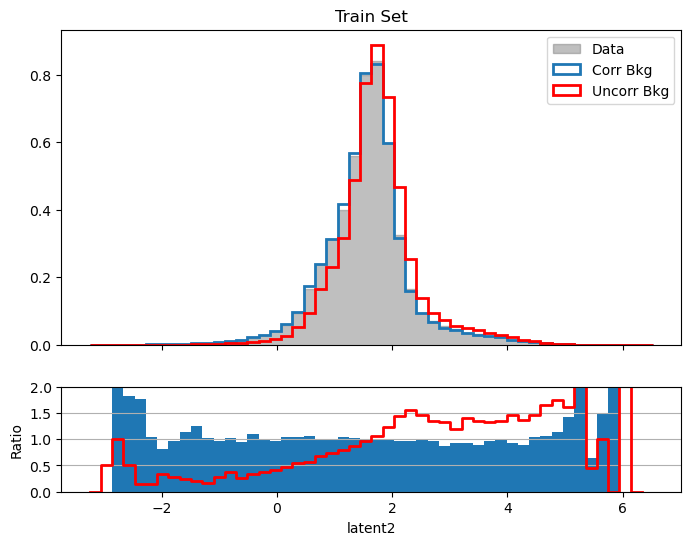

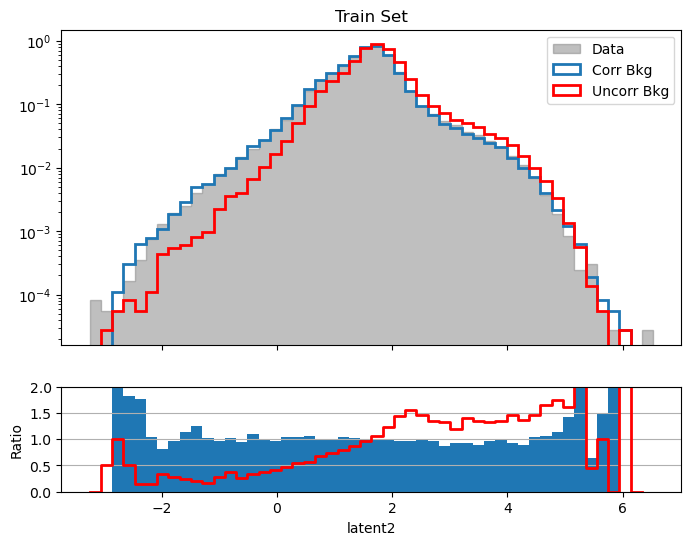

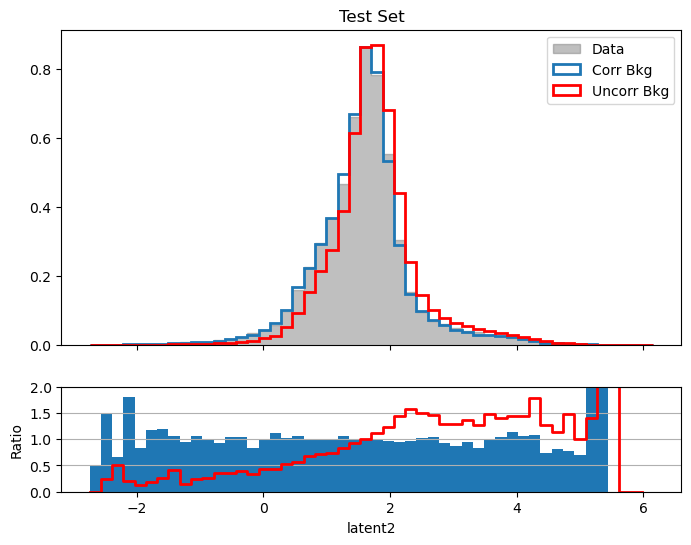

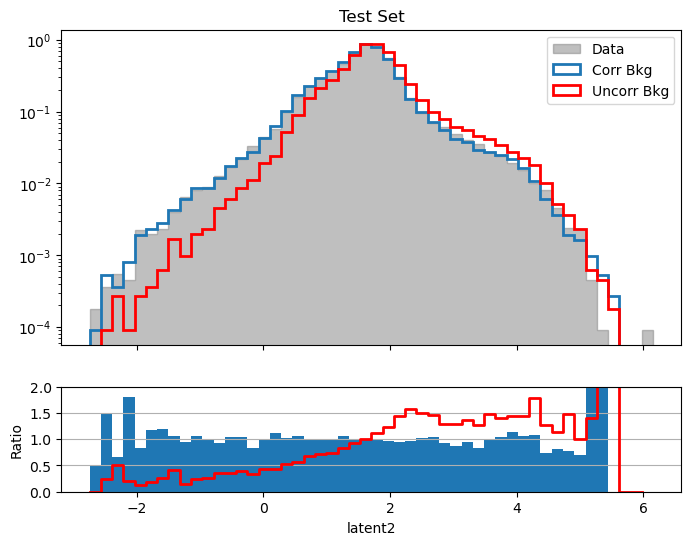

In [29]:
trainer.correctCurrent()
trainer.plotCurrent(50,ylim=[0,2])

In [30]:
trainer.stepForward()

# latent 4

Training flow bkgFlow_step3_latent3


Loss: -2.7225486207008363, p = 10: 100%|██████████| 686/686 [02:00<00:00,  5.70it/s] 


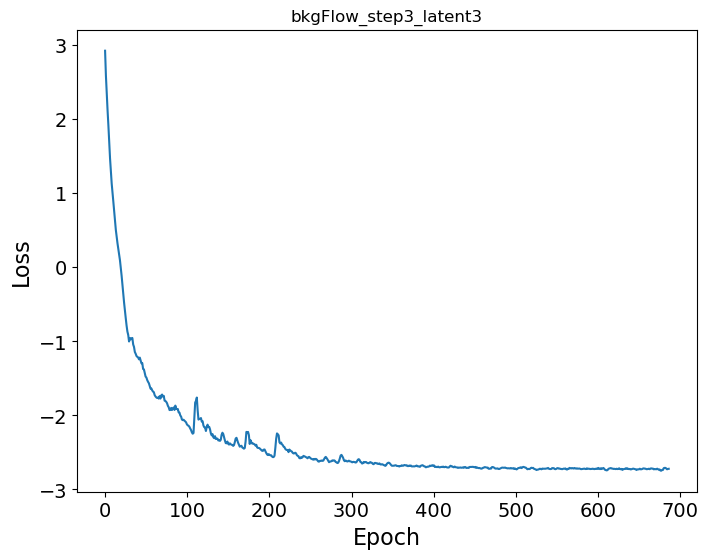

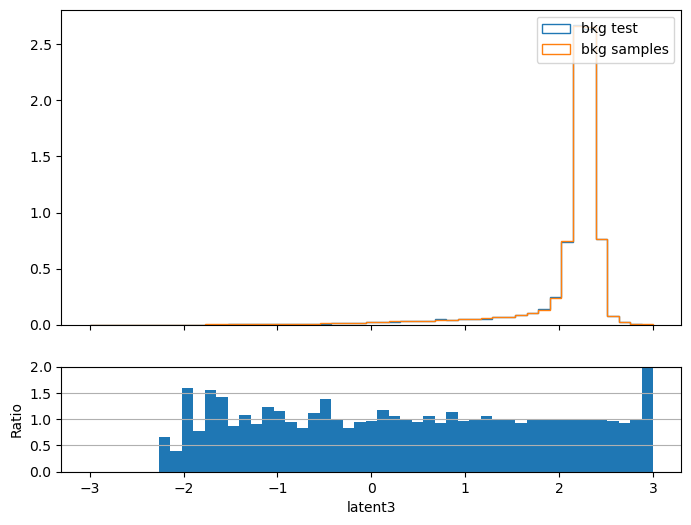

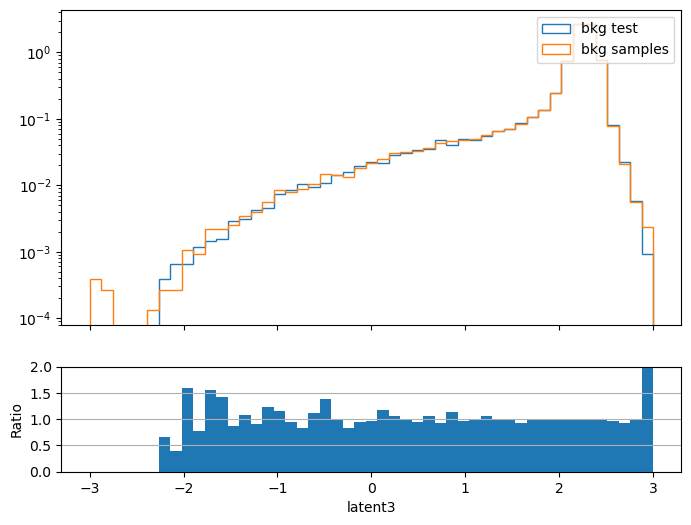

In [31]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":100,
             "num_layers":5,"num_bins":30,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 8192
n_epoch = 30
n_iter = n_epoch*b1_train.shape[0]//bs
trainer.trainCurrentBkg(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(bkg=True,ylim=[0,2])

Training flow dataFlow_step3_latent3


Loss: -2.4214602422714235, p = 162: 100%|██████████| 686/686 [01:59<00:00,  5.72it/s]


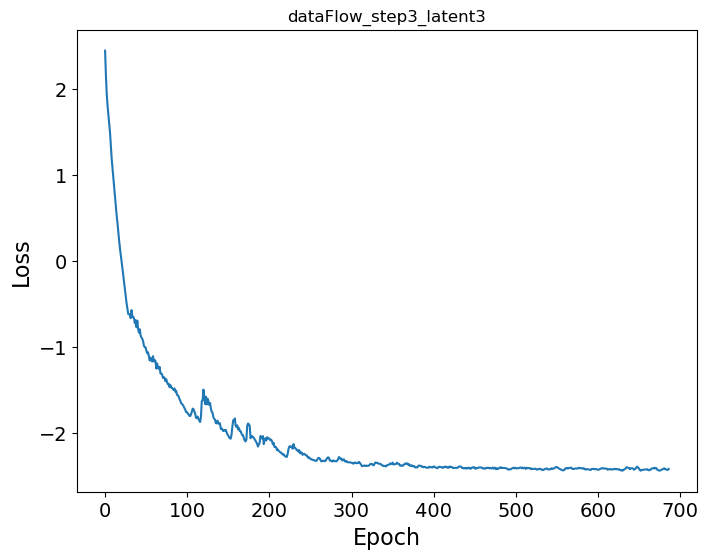

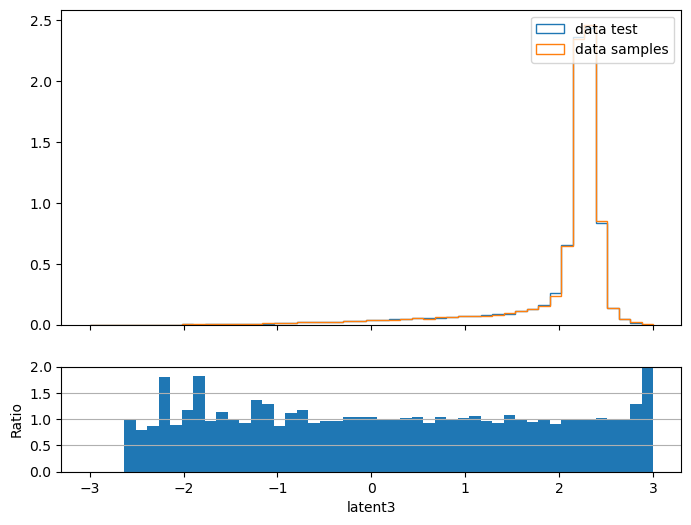

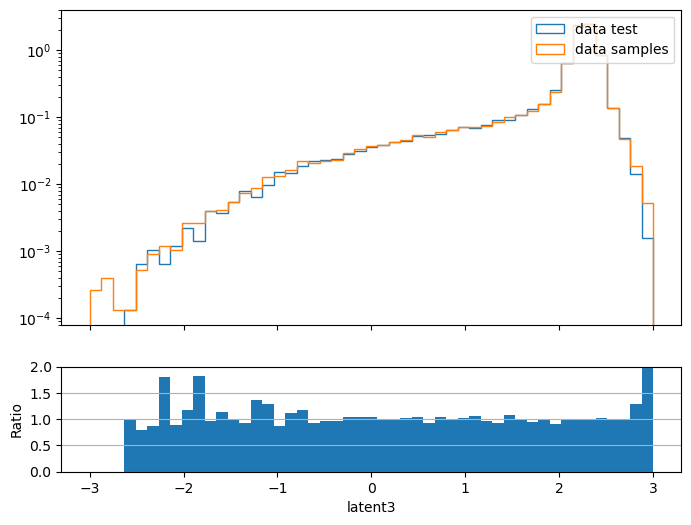

In [32]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":100,
             "num_layers":5,"num_bins":30,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 8192
n_epoch = 30
n_iter = n_epoch*b1_train.shape[0]//bs
trainer.trainCurrentData(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(data=True,ylim=[0,2])

100%|██████████| 7/7 [00:00<00:00, 14.23it/s]


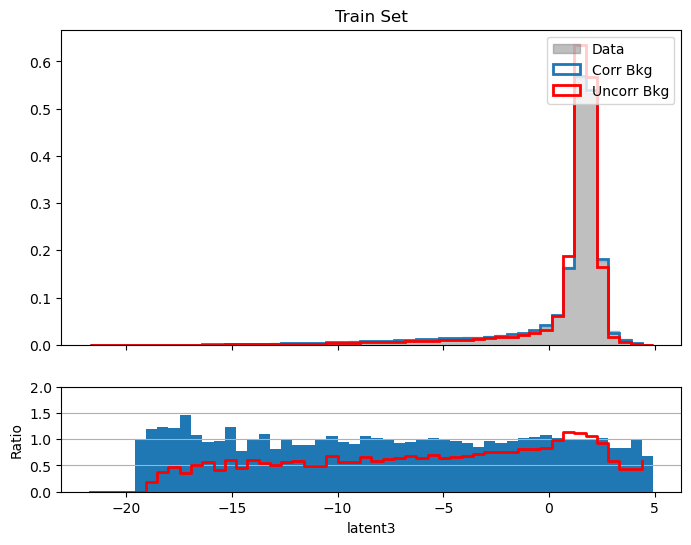

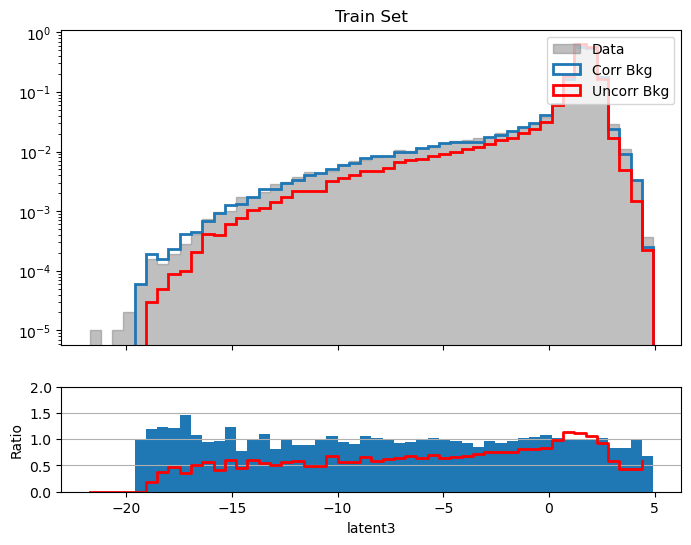

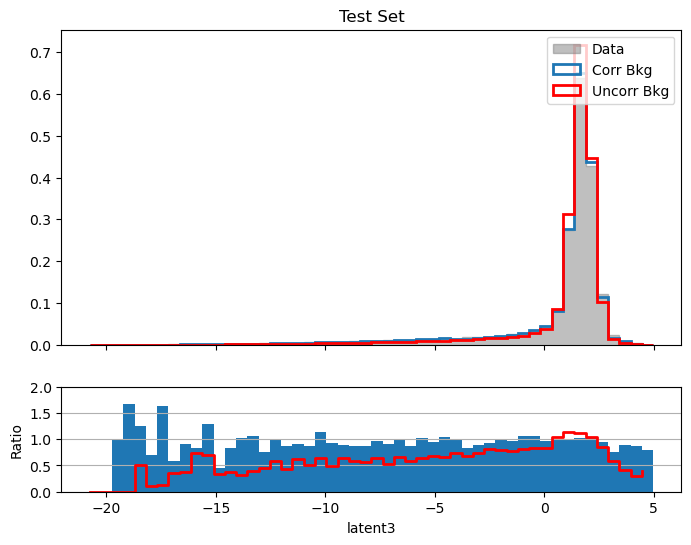

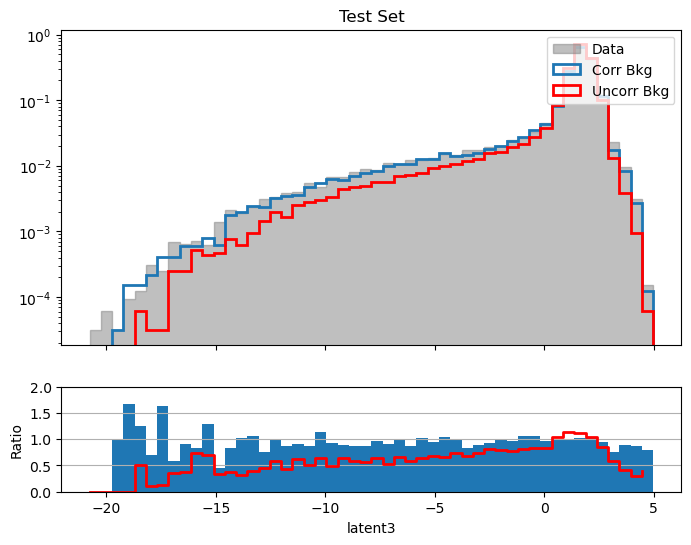

In [16]:
trainer.correctCurrent()
trainer.plotCurrent(50,ylim=[0,2])

In [17]:
save = np.concatenate([trainer.correctedBkg_test[v] for v in fitvars],axis=1)

In [6]:
model_dir = "LHCO_contrastive_RDtoBB1_jet1_v3"
corrector = qrnn.chainedNFCorrector(f"NF_models_QR_general/{model_dir}/")
corr_rd_test = corrector.correctFull(rd_test)
corr_rd_test = np.concatenate([corr_rd_test[v] for v in fitvars],axis=1)

[]


100%|██████████| 7/7 [00:00<00:00, 14.83it/s]


[0]


100%|██████████| 7/7 [00:00<00:00, 28.55it/s]


[0, 1]


100%|██████████| 7/7 [00:00<00:00, 31.18it/s]


[0, 1, 2]


100%|██████████| 7/7 [00:00<00:00, 30.99it/s]


In [9]:
base = "/nobackup/users/sambt/QR_samples/LHCO/contrastive/"
f_rd_morph = f"{base}/morphed_rd_bkg_latent_v3.h5"
with h5py.File(f_rd_morph,'w') as fout:
    fout.create_dataset('space',data=corr_rd_test)